#Hasonlóság fogalma és a dimmenzó csökkentés

Az elmúlt órákon megismerkedtünk a **DataFrame-ek** kezelésével, a különböző **vizualizációs eszközökkel**, valamint az NLP alapjaival.
Megtapasztaltuk, hogy az adatok tulajdonságait a **feature-ök** (valójában vektorok) írják le. (például az Iris adathalmaznál a levelek hossza és szélessége) Láttuk azt is, hogy ezek a jellemzők groupby-val és grafikonokkal szemléletesen csoportokat rajzolnak ki.  Az NLP példákból pedig kiderült, hogy a **mondatokat is reprezentálhatjuk vektorokkal**.

Sajnos azonban az adataink nem mindig csak 4–5 feature-ből állnak, hanem – ahogy az NLP-ben is láttuk – **néha több ezer jellemzőt kell kezelnünk**, amit az eddig megismert módszerekkel már nem könnyű átlátni és elemezni.

Ezért önmagában a vizuális ábrázolás szépsége nem elegendő: szükség van **konkrét mérőszámokra és eszközökre**, amelyekkel **csoportokat kijelölhetünk, összehasonlíthatunk és leegyszerűsíthetünk**.

Ennek két alapvető módja:

- **Hasonlóság mérése** – mennyire „közel” vannak egymáshoz az adatok.
- **Dimenziócsökkentés** – hogyan tudjuk az adatokat egyszerűbb, áttekinthetőbb térbe vetíteni úgy, hogy közben a lényegi szerkezet megmaradjon.

Ebben a fejezetben ezekkel a módszerekkel foglalkozunk részletesebben.

### Mi az a hasonlóság?

A **hasonlóság mérése** azt mutatja meg, hogy két adatpont mennyire áll közel egymáshoz a térben.
- Ha két pont közel van egymáshoz, akkor **hasonlóbbak**.
- Ha távol vannak egymástól, akkor **kevésbé hasonlók**.

Hasonlóságot mérhetünk két fő módon:
- **Távolság-alapú mérés**  - pl. *Euklideszi távolság*, amely a fizikai távolságot számítja.
- **Irány-alapú mérés** - pl. *Kozinusz-hasonlóság*, amely a vektorok szögét vizsgálja.
- **Metszet-alapú mérés** – pl. *Jaccard-hasonlóság*, amely azt mutatja meg, hogy két halmaz vagy bináris vektor elemei mennyire fedik egymást.  

### Euklideszi távolság

Euklideszi távolság azt méri, hogy két pont milyen messze van egymástól egy síkban vagy térben.
- Ez a hétköznapi "vonalzóval mért" távolság megfelelője.

Matematikai képlet (2D térben):

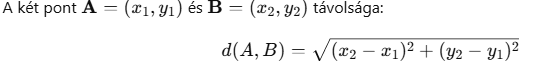

Ez kiterjeszthető többdimenziós vektorokra is!

In [4]:
import numpy as np

# Két pont vektorként
A = np.array([2, 3])
B = np.array([5, 7])

# Euklideszi távolság számítása
euclidean_distance = np.linalg.norm(A - B)
print("Euklideszi távolság:", euclidean_distance)


Euklideszi távolság: 5.0


Ez azt jelenti, hogy az A és B pont közötti távolság 5 egység.

###Koszinusz hasonlóság
A kozinusz hasonlóság nem a távolságot méri, hanem a vektorok közötti szöget.
- Ha két vektor egy irányba mutat, akkor nagyon hasonlók!
- Ha merőlegesek egymásra, akkor teljesen eltérők!

Matematikai képlet:

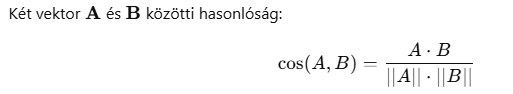

A számlálóban a vektorok skaláris szorzata van.
- A nevezőben a vektorok hosszának szorzata található.
- Az eredmény -1 és 1 között van:


- 1  -> teljesen egyforma irányú vektorok (maximálisan hasonlók).
- 0  -> teljesen eltérő (merőleges) vektorok.
- -1 -> teljesen ellentétes irányú vektorok.

In [5]:
from numpy.linalg import norm

# Két vektor
A = np.array([2, 3])
B = np.array([5, 7])

# Kozinusz hasonlóság számítása
cosine_similarity = np.dot(A, B) / (norm(A) * norm(B))
print("Kozinusz hasonlóság:", cosine_similarity)


Kozinusz hasonlóság: 0.9994801143396996


### Euklideszi távolság vs. Kozinusz-hasonlóság

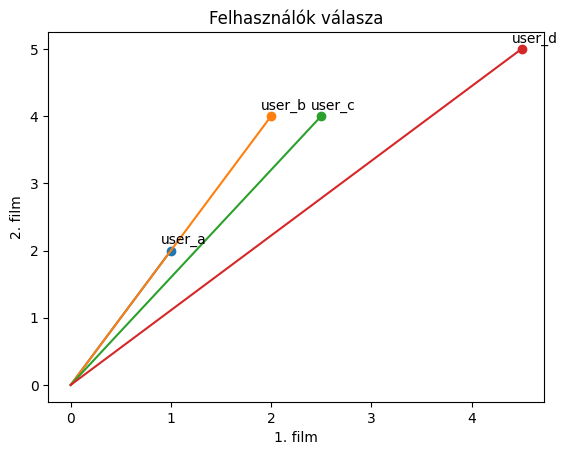

A két mérőszám alapvetően mást vizsgál:

- **Euklideszi távolság**: azt nézi, hogy a két pont **milyen messze van egymástól a térben**.  
  - Például a `user_a` és `user_c` pont között a távolság nagyobb, mint `user_a` és `user_b` között.  
  - A különbség a „vonallal mért” távolság.

- **Kozinusz-hasonlóság**: azt vizsgálja, hogy a két pontot az origóból húzott vektorok **milyen szöget zárnak be**.  
  - Ha a szög kicsi (vektorok közel azonos irányba mutatnak), akkor a pontok **hasonlónak** számítanak, még akkor is, ha az egyik távolabb van az origótól.  
  - Ezért `user_a` és `user_b` hasonlósága nagy (0 szög), míg `user_a` és `user_c`-é kicsi, mert más irányba mutat.

👉 Röviden:  
- Az **Euklideszi távolság** a *távolságot* méri.  
- A **Kozinusz-hasonlóság** az *irányt* méri.  


### Hasonlóság mérése az IRIS dataset-en

- A hasonlóság mérése nem csak két pont között lehetséges, hanem vektorok között is.
- Ily módon bármilyen tabuláris adat összehasonlitható.
- Vizsgáljuk meg a hasonóság módszerét az IRIS adathalmazon.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from scipy.spatial.distance import euclidean
from sklearn.metrics.pairwise import cosine_similarity
from numpy.linalg import norm

# Iris dataset betöltése
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target  # Címkék (0 = setosa, 1 = versicolor, 2 = virginica)


In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
# Két minta kiválasztása az IRIS datasetből
A = df.iloc[0, :-1].values  # Az első minta
B = df.iloc[50, :-1].values  # Az 50. minta (másik osztályból)

In [9]:
# Euklideszi távolság számítása
euclidean_dist = euclidean(A, B)

# Kozinusz hasonlóság számítása
cosine_sim = np.dot(A, B) / (norm(A) * norm(B))

In [11]:
# Táblázat a hasonlóságokkal
comparison_table = pd.DataFrame({
                                    "Feature": iris.feature_names,
                                    "A (Setosa)": A,
                                    "B (Versicolor)": B
                                })

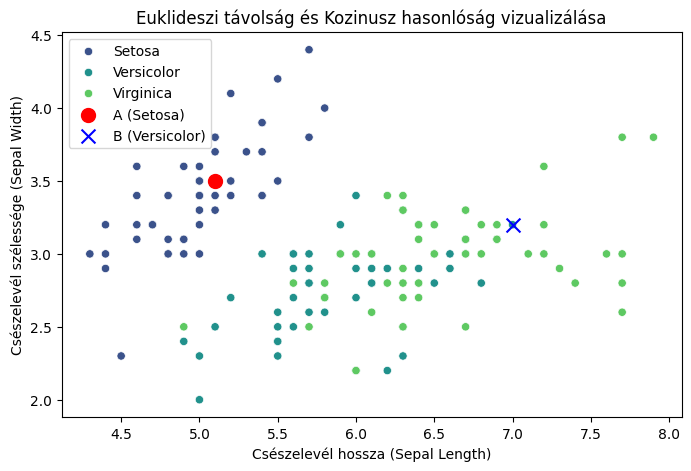

Euklideszi távolság A és B között: 4.0037
Kozinusz hasonlóság A és B között: 0.9284


In [12]:
# Vizualizáció: scatterplot az első két feature alapján
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="sepal length (cm)", y="sepal width (cm)", hue=df["species"].map({0: "Setosa", 1: "Versicolor", 2: "Virginica"}), palette="viridis")
plt.scatter(A[0], A[1], color="red", label="A (Setosa)", marker="o", s=100)
plt.scatter(B[0], B[1], color="blue", label="B (Versicolor)", marker="x", s=100)
plt.legend()
plt.title("Euklideszi távolság és Kozinusz hasonlóság vizualizálása")
plt.xlabel("Csészelevél hossza (Sepal Length)")
plt.ylabel("Csészelevél szélessége (Sepal Width)")
plt.show()

# Kiírás
print(f"Euklideszi távolság A és B között: {euclidean_dist:.4f}")
print(f"Kozinusz hasonlóság A és B között: {cosine_sim:.4f}")


Mit láthatunk:
- Euklideszi távolság (A és B között): 4.0037 -> Fizikai távolság a térben.
- Kozinusz hasonlóság (A és B között): 0.9284 -> A vektorok majdnem egy irányba mutatnak, vagyis nem teljesen eltérőek.

 Értelmezés:

- A két pont távolsága viszonylag nagy (4.00), ami azt jelenti, hogy a két virágfaj között mérhető különbség van.
- A kozinusz hasonlóság viszont 0.928, ami arra utal, hogy bár különböznek, még mindig van némi hasonlóság közöttük (nem teljesen merőlegesek egymásra a térben).

### Jaccard-hasonlóság

A Jaccard-hasonlóság azt méri, hogy két halmaz vagy bináris vektor mennyire fedi egymást.

- Más szóval: a közös elemek aránya az összes eltérő elemhez viszonyítva.
- Tipikusan bináris adatoknál (pl. attribútum jelen van / nincs) használjuk.

Matematikai képlet:

Ha \( A \) és \( B \) két halmaz, akkor:

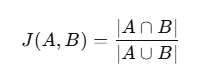

ahol:
- J(A,B) = 1 -> teljesen azonos halmazok
- J(A,B) = 0 -> nincs közös elem

Ez a mérőszám különösen hasznos szövegek, bináris jellemzők vagy kategóriák összehasonlításánál.


In [13]:
from sklearn.metrics import jaccard_score

# Két bináris vektor (pl. attribútum jelen van = 1, nincs = 0)
A = [1, 0, 1, 1, 0, 1]
B = [1, 1, 0, 1, 0, 0]

# Jaccard-hasonlóság számítása
similarity = jaccard_score(A, B)
print("Jaccard-hasonlóság A és B között:", similarity)


Jaccard-hasonlóság A és B között: 0.4


Magyarázat:

A = [1, 0, 1, 1, 0, 1]

B = [1, 1, 0, 1, 0, 0]

- Metszet: azok a helyek, ahol mindkettő 1 -> [1, 0, 0, 1, 0, 0] -> összesen 2 db.
- Unió: azok a helyek, ahol legalább az egyik 1 -> [1, 1, 1, 1, 0, 1] -> összesen 5 db.

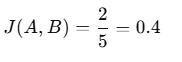

### Mikor jobb a Jaccard-hasonlóság?

Az **Euklideszi távolság** és a **Koszinusz-hasonlóság** főként folytonos numerikus vektorokra értelmezhetők.  
Ha azonban **bináris OHE (One-Hot Encoding) vektorokkal** dolgozunk (pl. kategóriák, címkék, attribútumok jelenléte), akkor ezek gyakran félrevezetők vagy nehezen értelmezhetők. (**Figyelem:** az NLP által készitett OHE (one hot encoded) is bináris vektor)

Ilyenkor a **Jaccard-hasonlóság** a legjobb választás, mert azt méri, hogy **mennyi a közös 1-es attribútum** az összes 1-hez képest.  
Ez különösen hasznos például filmek műfajainál, betegségek diagnóziskódjainál vagy vásárlói érdeklődési köröknél.


In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.metrics import jaccard_score

# Példa: három film műfajokkal (OHE)
# Műfajok: Action, Comedy, Drama, Sci-Fi
df = pd.DataFrame([
                      [1, 0, 0, 0],  # Film A: csak Action
                      [0, 1, 0, 0],  # Film B: csak Comedy
                      [1, 0, 0, 1],  # Film C: Action + Sci-Fi
                  ], columns=["Action", "Comedy", "Drama", "Sci-Fi"],
                    index=["Film A", "Film B", "Film C"])

display(df)

# Vektorok
A, B, C = df.iloc[0].values, df.iloc[1].values, df.iloc[2].values

# --- Euklideszi távolság ---
dist_AB = euclidean_distances([A], [B])[0][0]
dist_AC = euclidean_distances([A], [C])[0][0]

# --- Cosine hasonlóság ---
cos_AB = cosine_similarity([A], [B])[0][0]
cos_AC = cosine_similarity([A], [C])[0][0]

# --- Jaccard hasonlóság ---
jac_AB = jaccard_score(A, B)
jac_AC = jaccard_score(A, C)

print("Euklideszi távolság (A-B):", dist_AB)
print("Euklideszi távolság (A-C):", dist_AC)

print("\nCosine hasonlóság (A-B):", cos_AB)
print("Cosine hasonlóság (A-C):", cos_AC)

print("\nJaccard hasonlóság (A-B):", jac_AB)
print("Jaccard hasonlóság (A-C):", jac_AC)


,Action,Comedy,Drama,Sci-Fi
Film A,1,0,0,0
Film B,0,1,0,0
Film C,1,0,0,1


Euklideszi távolság (A-B): 1.4142135623730951
Euklideszi távolság (A-C): 1.0

Cosine hasonlóság (A-B): 0.0
Cosine hasonlóság (A-C): 0.7071067811865475

Jaccard hasonlóság (A-B): 0.0
Jaccard hasonlóság (A-C): 0.5


### Mit látunk?

Film A = Action, Film B = Comedy, Film C = Action+Sci-Fi

- **Euklideszi:** számokat ad, de nehezen értelmezhető a bináris kategóriáknál.
- **Cosine:** A–C között 0.707 -> mutat némi hasonlóságot, de nem intuitív.
- **Jaccard:**
  - A–B = 0 -> nincs közös műfaj
  - A–C = 0.5 -> 1 közös műfaj a 2-ből (tiszta értelmezés).

### Legközelebbi szomszédok

A **hasonlóság** nemcsak két elem közötti távolság mérésére használható, hanem arra is, hogy
egy teljes adathalmazt **csoportosítsunk** és **összehasonlítsunk**.

- Egy kiválasztott (ismert) elemhez(vagy elemekhez) kiszámíthatjuk a hasonlóságot vagy távolságot az összes többi elemhez képest.  
- Ezután ki tudjuk listázni a **legközelebbi szomszédokat**, vagyis a hozzá legjobban hasonlító elemeket.  
- Ez a gondolat az alapja a **K-Nearest Neighbors (KNN)** algoritmusnak is, amely az egyik legegyszerűbb, de gyakran hatékony osztályozási módszer.  

**Érdekesség:**
- Ha a szomszédok mind ugyanabba az osztályba tartoznak, akkor a vizsgált elem valószínűleg oda illik.  
- Ha vegyes szomszédokat találunk, az azt jelezheti, hogy az elem egy határterületen van két osztály között.  

Nézzünk egy példát az **Iris dataseten**, ahol kiválasztunk egy virágot, és megkeressük a hozzá leginkább hasonló (legközelebbi) mintákat távolság alapú összehasonlítással.


In [15]:
# töltsük be a megfelelő csomagot
from scipy.spatial.distance import cosine

In [19]:
# Iris dataset betöltése
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target  # Címkék (0 = setosa, 1 = versicolor, 2 = virginica)

In [25]:
# Kiválasztunk egy mintát (pl. egy Versicolor virágot)
query_index = 75  # Egy Versicolor minta
query_sample = df.iloc[query_index, :-1]  # A kiválasztott minta adatai
display(query_sample)

,75
sepal length (cm),6.6
sepal width (cm),3.0
petal length (cm),4.4
petal width (cm),1.4
species,1.0


In [26]:
query_sample =  query_sample.values

In [27]:
# Az összes többi minta közötti távolság számítása (Euklideszi távolság)
df["distance"] = df.iloc[:, :-1].apply(lambda x: cosine(x.values, query_sample), axis=1)

In [28]:
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,distance
0,5.1,3.5,1.4,0.2,0,0.078425
1,4.9,3.0,1.4,0.2,0,0.066816
2,4.7,3.2,1.3,0.2,0,0.076861
3,4.6,3.1,1.5,0.2,0,0.064611
4,5.0,3.6,1.4,0.2,0,0.081553


In [29]:
# Az 5 legközelebbi minta kiválasztása (kivéve magát)
closest_samples = df.nsmallest(6, "distance").iloc[1:]  # Első a saját minta, ezért kihagyjuk
closest_samples

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,distance
74,6.4,2.9,4.3,1.3,1,0.000038
65,6.7,3.1,4.4,1.4,1,0.000050
50,7.0,3.2,4.7,1.4,1,0.000073
71,6.1,2.8,4.0,1.3,1,0.000084
82,5.8,2.7,3.9,1.2,1,0.000158


/tmp/ipython-input-557740354.py:8: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(row["sepal length (cm)"], row["sepal width (cm)"], color="blue", marker="x", s=100, edgecolors="black")


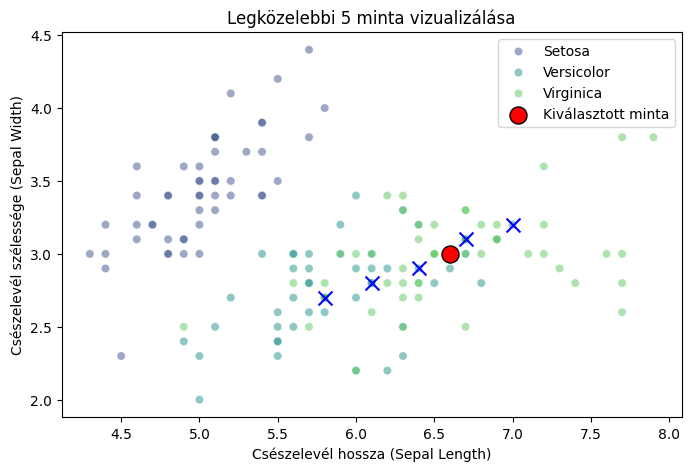

In [30]:
# Scatterplot a legközelebbi 5 elemmel
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="sepal length (cm)", y="sepal width (cm)", hue=df["species"].map({0: "Setosa", 1: "Versicolor", 2: "Virginica"}), palette="viridis", alpha=0.5)
# Kiválasztott minta megjelölése piros színnel
plt.scatter(query_sample[0], query_sample[1], color="red", label="Kiválasztott minta", marker="o", s=150, edgecolors="black")
# Legközelebbi minták megjelölése kék színnel
for idx, row in closest_samples.iterrows():
    plt.scatter(row["sepal length (cm)"], row["sepal width (cm)"], color="blue", marker="x", s=100, edgecolors="black")
plt.legend()
plt.title("Legközelebbi 5 minta vizualizálása")
plt.xlabel("Csészelevél hossza (Sepal Length)")
plt.ylabel("Csészelevél szélessége (Sepal Width)")
plt.show()


Mit látunk:

- Kiválasztottam egy Versicolor mintát a datasetből (75. sor).
- Kiszámoltam az 5 legközelebbi másik mintát euklideszi távolság alapján.
- Vizualizáltam a kiválasztott mintát (piros) és a legközelebbi pontokat (kék x).
- A táblázat tartalmazza a legközelebbi minták adatait és távolságait.

Értelmezés:

- A legközelebbi minta távolsága: 0.1414 → Ez azt jelenti, hogy az egyik.
- Versicolor minta nagyon hasonló a kiválasztotthoz.
- A többi távolság kicsivel nagyobb, de mindegyik azonos osztályból (Versicolor) származik.
- A vizualizáció mutatja, hogy a Versicolor csoport belső struktúrája jól elkülönül.

### K-Nearest Neighbors (KNN) - távolság/hasonlóság alapú osztályozó

Mi az a K-Nearest Neighbors (KNN) osztályozó?
- Egy új adatpontot a hozzá legközelebb lévő K darab szomszéd osztálycímkéje alapján sorolunk be.
- A leggyakoribb osztályba soroljuk az új adatpontot.
- KNN nem tanul előre, minden új lekérdezéskor számítja ki a szomszédokat (Lazy Learning).

Lépései:
- Távolságok kiszámítása az új pont és az összes meglévő pont között (pl. Euklideszi távolság).
- A K legközelebbi pont kiválasztása.
- Többségi szavazás -> Az új pontot a legtöbbször előforduló osztályba soroljuk.

### Példa: KNN osztályozó az Iris dataset-en

Az IRIS dataset 3 osztályt tartalmaz:

- Setosa (0)
- Versicolor (1)
- Virginica (2)

KNN modell betanítása és tesztelése:
- Betöltjük az Iris datasetet
- Szétválasztjuk a tanuló (80%) és teszt (20%) adatokat
- KNN osztályozót tanítunk K=5 szomszéddal
- Előrejelzéseket készítünk és értékeljük a pontosságot

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Iris dataset betöltése
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target  # Címke (0 = Setosa, 1 = Versicolor, 2 = Virginica)

In [32]:
# 2. Tanuló és tesztadatok szétválasztása
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df["species"], test_size=0.2, random_state=42)

In [33]:
# 3. Adatok normalizálása (KNN érzékeny a skálázásra!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Mi az a Scaler (Skálázás)?

 A Scaler egy olyan eszköz, amely az adatok értékeit egy egységes skálára hozza.
- Sok gépi tanulási algoritmus érzékeny az egyes változók eltérő tartományára.
- Ha az egyik feature tartománya 0-1000, míg a másik 0-1, akkor az egyik dominálni fog a számításokban.
-  Az adatskálázás segít az algoritmusoknak hatékonyabban működni.
- Különösen fontos távolságalapú modelleknél, például a KNN-nél, mert a nagy értékű változók eltorzíthatják a távolságmérést.

In [38]:
# 4. KNN osztályozó betanítása (K=5)
# Itt a K-Nearest Neighbors algoritmust tanítjuk be.
# - n_neighbors=5 azt jelenti, hogy minden új minta osztályozásához
#   az 5 legközelebbi szomszédot keressük meg.
# - metric="cosine" beállítással a hasonlóságot a koszinusz szög alapján mérjük,
#   így az algoritmus az iránybeli hasonlóságot veszi figyelembe, nem a nyers távolságot.
knn = KNeighborsClassifier(n_neighbors=5, metric="cosine")
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier(metric='cosine')

In [39]:
# 5. Előrejelzés a teszt adatokra
y_pred = knn.predict(X_test_scaled)

In [40]:
df_res = X_test
df_res['target'] = y_test
df_res['predict'] = y_pred
display(df_res.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,predict
73,6.1,2.8,4.7,1.2,1,1
18,5.7,3.8,1.7,0.3,0,0
118,7.7,2.6,6.9,2.3,2,2
78,6.0,2.9,4.5,1.5,1,2
76,6.8,2.8,4.8,1.4,1,1


In [41]:
# 6. Modell pontosságának kiírása
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Modell pontossága: {accuracy:.4f}")

# 7. Osztályozási riport
print("\nOsztályozási riport:\n", classification_report(y_test, y_pred))

KNN Modell pontossága: 0.9333

Osztályozási riport:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.78      0.88         9
           2       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



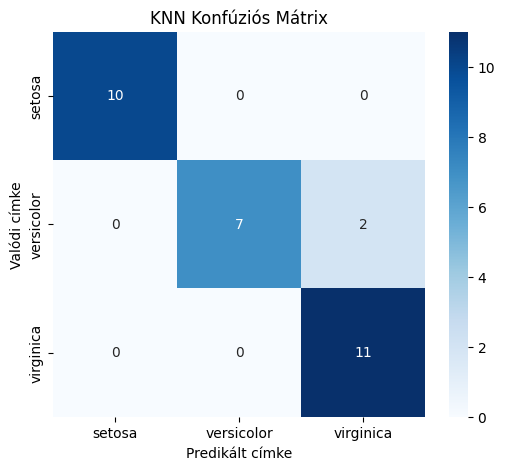

In [42]:
# 8. Konfúziós mátrix vizualizálása
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predikált címke")
plt.ylabel("Valódi címke")
plt.title("KNN Konfúziós Mátrix")
plt.show()

### Mi az a Konfúziós Mátrix?

A konfúziós mátrix egy táblázat, amely megmutatja egy osztályozási modell előrejelzéseinek teljesítményét.

### Mit láthatunk?

KNN Modell pontossága: ~97-100%

Konfúziós mátrix:

- Megmutatja, mely mintákat osztályozta helyesen és melyeket tévesen.
- Átlóban lévő értékek = helyesen osztályozott példák.
- Nem átlós elemek = téves osztályozások.
- Ha az osztályozó 100%-os pontosságot ér el, az azt jelenti, hogy az Iris dataset jól elkülöníthető.

### Hasonlóság mérése szöveges adathalmazon

A fentiekben már megismerkedtünk a hasonlóság mérésével **táblázatos (numerikus) adatok** esetén.  
Most azonban – az előző tananyaghoz kapcsolódva – visszakanyarodunk az **NLP világához**, és megnézzük, hogyan hasonlíthatunk össze **szöveges adatokat**.

A célunk nem az, hogy mélyebben belemerüljünk a természetes nyelvfeldolgozás (NLP) vagy a generatív AI módszereibe, hanem hogy áttekintsük azokat az **alapvető lehetőségeket**, amelyek akkor állnak rendelkezésünkre, ha az adataink nem hagyományos táblázatos formában jelennek meg.  

Ezek a módszerek nemcsak szövegeknél hasznosak, hanem más diszkrét attribútumoknál is, például **orvosi diagnóziskódok**, **molekulalisták**, vagy más, kategóriákból álló adatok összehasonlításánál.


### BOW használata a hasonlóság számitásban

- A BagOfWords-ot használhatjuk vektorképzésre (kategorikus vagy szövegse adatoknál)
- Az igy kapott numerikus vektrok már összehasonlitahtók



In [46]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# 1. Példa szövegek
documents = [
    "I love machine learning and NLP",
    "Machine learning is amazing",
    "I enjoy deep learning and AI",
    "Natural language processing is part of AI",
    "Deep learning and machine learning are related fields"
]

In [47]:
# 2. Bag-of-Words (BoW) vektorizáció
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(documents)

In [45]:
# 3. Kozinusz hasonlóság számítása az összes szöveg között
cosine_sim_bow = cosine_similarity(X_bow, X_bow)

# 4. Hasonlóságok táblázatos megjelenítése
df_sim_bow = pd.DataFrame(cosine_sim_bow, index=documents, columns=["Doc1", "Doc2", "Doc3", "Doc4", "Doc5"])

display(df_sim_bow.head())

,Doc1,Doc2,Doc3,Doc4,Doc5
I love machine learning and NLP,1.000000,0.447214,0.400000,0.000000,0.565685
Machine learning is amazing,0.447214,1.000000,0.223607,0.188982,0.474342
I enjoy deep learning and AI,0.400000,0.223607,1.000000,0.169031,0.565685
Natural language processing is part of AI,0.000000,0.188982,0.169031,1.000000,0.000000
Deep learning and machine learning are related fields,0.565685,0.474342,0.565685,0.000000,1.000000


### BoW + Jaccard-hasonlóság

A Bag-of-Words (BoW) vektorizációt nemcsak szótöbbség számítására, hanem **bináris jellemzők** előállítására is használhatjuk.  
Ebben az esetben minden szóhoz 0/1 értéket rendelünk aszerint, hogy **előfordul-e a dokumentumban**.  

Az így kapott bináris vektorok között a **Jaccard-hasonlóság** jól alkalmazható, mert a közös szavak arányát méri az összes különböző szóhoz képest.  
- Ha két dokumentum teljesen azonos szavakat tartalmaz → hasonlóság = 1.  
- Ha nincs közös szó → hasonlóság = 0.  


In [50]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import pairwise_distances
import pandas as pd

# 1. Példa szövegek
documents = [
    "I love machine learning and NLP",
    "Machine learning is amazing",
    "I enjoy deep learning and AI",
    "Natural language processing is part of AI",
    "Deep learning and machine learning are related fields"
]

# 2. Bag-of-Words (BoW) vektorizáció
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(documents)

# 3. Bináris BoW mátrix (szó előfordul-e vagy sem)
X_bow_binary = (X_bow > 0).astype(int)

# 4. Jaccard-távolság számítása (1 - Jaccard-hasonlóság)
jaccard_dist = pairwise_distances(X_bow_binary.toarray(), metric="jaccard")

# 5. Hasonlóságmátrix (1 - távolság)
jaccard_sim = 1 - jaccard_dist

# 6. Táblázatos megjelenítés
df_sim_jaccard = pd.DataFrame(jaccard_sim,
                              index=["Doc1", "Doc2", "Doc3", "Doc4", "Doc5"],
                              columns=["Doc1", "Doc2", "Doc3", "Doc4", "Doc5"])

display(df_sim_jaccard)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


,Doc1,Doc2,Doc3,Doc4,Doc5
Doc1,1.000000,0.285714,0.250000,0.000000,0.333333
Doc2,0.285714,1.000000,0.125000,0.100000,0.222222
Doc3,0.250000,0.125000,1.000000,0.090909,0.333333
Doc4,0.000000,0.100000,0.090909,1.000000,0.000000
Doc5,0.333333,0.222222,0.333333,0.000000,1.000000


### Miért nem elég a BoW ?

Bag-of-Words (BoW) problémái:
- Nagyon nagy méretű vektorokat eredményeznek -> Minden egyedi szó egy külön dimenzió.
- Nem érzékelik a szavak közötti jelentésbeli kapcsolatot.
- A szavak sorrendjét nem veszik figyelembe.
- Doc1 és Doc4 között a kozinusz hasonlóság 0.0, ami azt jelenti, hogy ezek teljesen eltérőek.
- Azonban ez nem feltétlenül igaz jelentés szempontjából, hanem csak azt jelenti, hogy nincsenek közös szavak a két dokumentumban.


### Mi az a TF-IDF?

A **TF-IDF** (Term Frequency – Inverse Document Frequency) egy szövegbányászati módszer, amely megmutatja, mennyire fontos egy szó egy adott dokumentumban az egész korpuszhoz viszonyítva.  

- **TF (Term Frequency):** azt méri, hogy egy szó hányszor fordul elő a dokumentumban.  
- **IDF (Inverse Document Frequency):** azt súlyozza, hogy a szó mennyire ritka az összes dokumentumban.  

Az eredmény:  
- A gyakori, de mindenhol előforduló szavak (pl. „the”, „is”) alacsony súlyt kapnak.  
- A ritkább, de egy dokumentumban gyakran megjelenő szavak magasabb súlyt kapnak.  

Ezáltal a TF-IDF segít kiemelni a **dokumentum szempontjából releváns szavakat**, és csökkenti a „zaj” (gyakori, de jelentéktelen szavak) hatását.


### TF-IDF
Azzal, hogy a TF-IDF csökkenti a gyakran előforduló szavak súlyát, kiemeli azokat a szavakat, amik fontosak lehetnek két dokumentum hasonlóságában.

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. TF-IDF vektorizáció alkalmazása (Bag-of-Words helyett)
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(documents)

# 2. Kozinusz hasonlóság számítása a TF-IDF vektorok között
cosine_sim_tfidf = cosine_similarity(X_tfidf, X_tfidf)

# 3. Hasonlóságok táblázatos megjelenítése TF-IDF esetén
df_sim_tfidf = pd.DataFrame(cosine_sim_tfidf, index=documents, columns=["Doc1", "Doc2", "Doc3", "Doc4", "Doc5"])

# 4. Eredmények megjelenítése
display(df_sim_tfidf.head())


,Doc1,Doc2,Doc3,Doc4,Doc5
I love machine learning and NLP,1.000000,0.274793,0.243904,0.000000,0.354232
Machine learning is amazing,0.274793,1.000000,0.116567,0.166789,0.288909
I enjoy deep learning and AI,0.243904,0.116567,1.000000,0.148041,0.410513
Natural language processing is part of AI,0.000000,0.166789,0.148041,1.000000,0.000000
Deep learning and machine learning are related fields,0.354232,0.288909,0.410513,0.000000,1.000000


### Nem veszi figyelembe a szavak sorrendjét
- BoW egyszerű szógyakorisági vektorként kezeli a dokumentumokat.
- Ha két dokumentum ugyanazokat a szavakat tartalmazza, de teljesen más sorrendben, akkor ugyanolyan vektort kapnak, és 1.0 hasonlóságot mutathatnak.
- Ez probléma lehet, ha a szavak sorrendje fontos a jelentés szempontjából.

Megoldás:

- N-gramokat is bevonhatunk a BoW vektorizációba.


In [ ]:
# 1. N-gram alapú BoW vektorizáció alkalmazása (figyelembe veszi a szavak sorrendjét)
vectorizer_ngram = CountVectorizer(ngram_range=(2, 3))  # Bigramek és trigramok használata
X_ngram = vectorizer_ngram.fit_transform(documents)

# 2. Kozinusz hasonlóság számítása az N-gram BoW vektorok között
cosine_sim_ngram = cosine_similarity(X_ngram, X_ngram)

# 3. Hasonlóságok táblázatos megjelenítése N-gram BoW esetén
df_sim_ngram = pd.DataFrame(cosine_sim_ngram, index=documents, columns=["Doc1", "Doc2", "Doc3", "Doc4", "Doc5"])

# 📌 4. Eredmények megjelenítése
display(df_sim_ngram.head())


,Doc1,Doc2,Doc3,Doc4,Doc5
I love machine learning and NLP,1.000000,0.169031,0.142857,0.0,0.209657
Machine learning is amazing,0.169031,1.000000,0.000000,0.0,0.124035
I enjoy deep learning and AI,0.142857,0.000000,1.000000,0.0,0.314485
Natural language processing is part of AI,0.000000,0.000000,0.000000,1.0,0.000000
Deep learning and machine learning are related fields,0.209657,0.124035,0.314485,0.0,1.000000


### Nem érzékeny a szinonimákra

Ha két szöveg nagyon hasonló, de eltérő szinonimákat használ, akkor a BoW módszer nem fog hasonlóságot találni.

Példa:
- "I love deep learning"
- "I enjoy neural networks"

A két mondat nagyon hasonló jelentéssel bír, de mivel nincsenek közös szavak, az algoritmus 0.0 hasonlóságot adhat.

Megoldás:
- Word Embeddings (Word2Vec, GloVe, BERT) használata, amelyek jelentésbeli hasonlóságot is figyelembe vesznek.

### Mi az a Word Embeddings?

- A **Word Embeddings** egy olyan módszer, amely **a szavakat egy többdimenziós térben vektorokként ábrázolja**.
- A hasonló jelentésű szavak közelebb helyezkednek el egymáshoz ebben a térben.

Példa:
- **BoW** és **TF-IDF**: "dog" és "puppy" teljesen eltérő vektorokat kapnak.
- **Word Embeddings**: "dog" és "puppy" vektorai nagyon hasonlóak lesznek.


Word Embedding modellek:

- **Word2Vec** (Google, 2013) -> Szavakat a környezetük alapján tanít.
- **GloVe** (Stanford, 2014) -> Együtt-fordulási valószínűségeket használ.
- **FastText** (Facebook, 2016) -> Szótöredékeket is figyelembe vesz.
- **BERT** (Google, 2018) -> Kontextusfüggő szavak, teljes mondatokhoz alkalmazható.

Bővebben a Word2Vec-ről [itt](https://www.youtube.com/watch?v=hQwFeIupNP0)

In [ ]:
### Szükséges csomagok feltelpítése
pip install gensim numpy==1.26.4
###  Notebook újraindítása
import os
os.kill(os.getpid(), 9)
###  Újraindítás után folytassuk innen a cellák futtatását

In [ ]:
import gensim.downloader as api
import numpy as np
# 1. Word2Vec előre betanított modell betöltése
#word2vec_model = api.load("word2vec-google-news-300")
word2vec_model = api.load("glove-wiki-gigaword-50")

In [ ]:
# A "king" szó vector reprezentációja
word2vec_model["king"]

array([ 0.50451 ,  0.68607 , -0.59517 , -0.022801,  0.60046 , -0.13498 ,
       -0.08813 ,  0.47377 , -0.61798 , -0.31012 , -0.076666,  1.493   ,
       -0.034189, -0.98173 ,  0.68229 ,  0.81722 , -0.51874 , -0.31503 ,
       -0.55809 ,  0.66421 ,  0.1961  , -0.13495 , -0.11476 , -0.30344 ,
        0.41177 , -2.223   , -1.0756  , -1.0783  , -0.34354 ,  0.33505 ,
        1.9927  , -0.04234 , -0.64319 ,  0.71125 ,  0.49159 ,  0.16754 ,
        0.34344 , -0.25663 , -0.8523  ,  0.1661  ,  0.40102 ,  1.1685  ,
       -1.0137  , -0.21585 , -0.15155 ,  0.78321 , -0.91241 , -1.6106  ,
       -0.64426 , -0.51042 ], dtype=float32)

In [ ]:
# A "king" és a "queen" szavak koszinusz hasonlósága
np.dot(word2vec_model["king"], word2vec_model["queen"]) / (norm(word2vec_model["king"]) * norm(word2vec_model["queen"]))

0.7839044

In [ ]:
# A "king" és a "dog" szavak koszinusz hasonlósága
np.dot(word2vec_model["king"], word2vec_model["dog"]) / (norm(word2vec_model["king"]) * norm(word2vec_model["dog"]))

0.34048975

### Dimenziócsökkentés – Miért és hogyan?

A következő fontos téma a **dimenziócsökkentés**, amely különösen akkor hasznos, ha nagy és összetett adatokkal dolgozunk.  
Sokszor nem elég, ha az adatainkat egyszerűen csak tároljuk és vizualizáljuk: szükség van olyan módszerekre, amelyek képesek a **lényegi információt kiemelni**, miközben az adatok bonyolultságát csökkentik.

Nagy dimenziós adatok kezelése nehéz, mert:
- A nagyon széles táblázatok nehezen értelmezhetőek és vizualizálhatóak.  
- A gépi tanulási modellek teljesítménye romolhat túl sok feature esetén (dimenzióátok – *Curse of Dimensionality*).  
- Az adatok gyakran redundanciát tartalmaznak – sok oszlop hasonló információt hordoz.  
- A feldolgozás és tárolás költségesebb nagy dimenziószám mellett.  

A dimenziócsökkentés célja tehát, hogy **az adatainkat kisebb, áttekinthetőbb térbe vetítsük**, miközben a lehető legtöbb lényegi információt megőrizzük.  
Ez egyszerre segíti a **vizualizációt**, az **elemzést** és a **gépi tanulási modellek hatékonyságát**.  

**Megoldás:** dimenziócsökkentő technikák alkalmazása, mint például a **PCA (Principal Component Analysis)**, a **t-SNE** vagy a **UMAP**, amelyek képesek a magas dimenziós adatokat 2D vagy 3D térbe vetíteni.


### Dimenziócsökkentés PCA-val (Főkomponens-analízis)

A **PCA (Principal Component Analysis)** egy lineáris dimenziócsökkentő módszer, amely az adatok fő irányait (főkomponenseit) keresi meg.  
Ahelyett, hogy az eredeti feature-ök mentén ábrázolnánk az adatokat, új tengelyeket hoz létre, amelyekben:
- az első főkomponens a lehető legnagyobb varianciát magyarázza,  
- a második főkomponens a maradék legnagyobb varianciát, és így tovább.  

Így a sokdimenziós adatok nagy része **néhány főkomponenssel jól közelíthető**, miközben a zaj vagy a redundáns információ kiszűrhető.

Ez hasznos, mert:
- csökkenti a dimenziószámot (áttekinthetőbbé teszi az adatokat),  
- gyorsítja a gépi tanulási algoritmusokat,  
- segít a vizualizációban (pl. 2D/3D ábrák készítése),  
- kiszűri az erősen korreláló jellemzők okozta redundanciát.  

Lássunk egy példát, ahol a **Word2Vec vektorokat** PCA segítségével csökkentjük 2 dimenzióra, hogy könnyebben tudjuk őket vizualizálni és értelmezni.

**Fontos:** ez a módszer bármilyen más többdienziós adaton is dolgozhatna például az IRIS vagy a WINE dataset-en.

Bővebben a PCA-ról [itt](https://www.youtube.com/watch?v=FgakZw6K1QQ)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gensim.downloader as api
from sklearn.decomposition import PCA


# 2. Kiválasztunk néhány szót és a hozzájuk tartozó vektorokat
words = ["king", "queen", "man", "woman", "dog", "cat", "apple", "orange"]
vectors = np.array([word2vec_model[word] for word in words])



In [ ]:
print("Vektorok mérete:", vectors.shape)

Vektorok mérete: (8, 50)


In [ ]:
# 3. PCA alkalmazása a dimenzió csökkentésére (50 → 2 dimenzió)
pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(vectors)


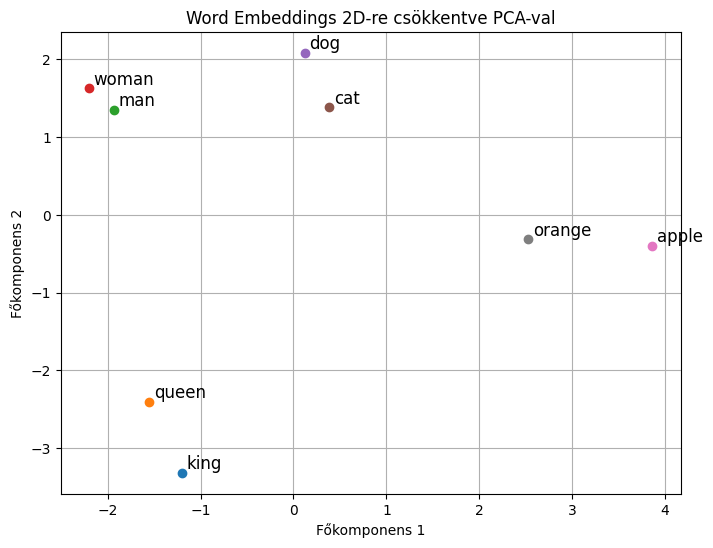

In [ ]:
# 4. Vizualizáció
plt.figure(figsize=(8, 6))
for word, coord in zip(words, reduced_vectors):
    plt.scatter(coord[0], coord[1])
    plt.text(coord[0]+0.05, coord[1]+0.05, word, fontsize=12)

plt.title("Word Embeddings 2D-re csökkentve PCA-val")
plt.xlabel("Főkomponens 1")
plt.ylabel("Főkomponens 2")
plt.grid()
plt.show()

Mit csináltunk?

- Betöltöttük az előre betanított Word Embeddings modellek kisebb változatát (50 dimenziós).
- PCA-val 2D-re csökkentettük a vektorokat.
- Megjelenítettük az eredményt egy scatter plot-on.
- A hasonló jelentésű szavak közelebb lesznek egymáshoz, például:


### Dimenziócsökkentés t-SNE-vel

A **t-SNE (t-Distributed Stochastic Neighbor Embedding)** egy nemlineáris dimenziócsökkentő algoritmus, amelyet gyakran használnak adatok vizualizálására.  

- Míg a PCA globálisan keresi meg az adatok fő irányait, a t-SNE kifejezetten a **lokális struktúrákat** próbálja megőrizni.  
- Ez azt jelenti, hogy ha két adatpont közel van egymáshoz a magas dimenziós térben, akkor a t-SNE is igyekszik őket közel tartani az alacsony dimenziós (pl. 2D) térben.  
- A módszer különösen hasznos akkor, ha az adatok **nemlineáris szerkezetet** tartalmaznak, és klaszterek, csoportok feltárása a cél.  

Hátránya, hogy lassabb, mint a PCA, és az eredmények a beállításoktól (pl. *perplexity*) is erősen függenek.  
Előnye viszont, hogy gyakran **sokkal szemléletesebb 2D ábrát** ad, ahol a természetes klaszterek jól elkülönülnek egymástól.

Bővebben a t-SNE-ről [itt](https://www.youtube.com/watch?v=NEaUSP4YerM)

In [52]:
from sklearn.manifold import TSNE

# 1. t-SNE alkalmazása a Word Embeddings-re (50 → 2 dimenzió)
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
reduced_vectors_tsne = tsne.fit_transform(vectors)

# 2. Vizualizáció
plt.figure(figsize=(8, 6))
for word, coord in zip(words, reduced_vectors_tsne):
    plt.scatter(coord[0], coord[1])
    plt.text(coord[0]+0.05, coord[1]+0.05, word, fontsize=12)

plt.title("Word Embeddings 2D-re csökkentve t-SNE-vel")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid()
plt.show()


NameError: name 'vectors' is not defined

### Dimenziócsökkentés t-SNE-vel az IRIS dataset-en

Az IRIS dataset jó példa arra, hogyan lehet dimenziócsökkentést alkalmazni valós adatokon.  
Míg az adathalmaz eredetileg 4 dimenziós (szirom- és csészelevél hossza és szélessége),  
a **t-SNE segítségével 2 dimenzióra vetíthetjük**, hogy szemléletesen vizualizáljuk a virágfajok közötti hasonlóságokat.  

A t-SNE különösen alkalmas arra, hogy **lokális szerkezeteket és klasztereket** mutasson meg, ezért jól elkülöníthetjük vele a három faj (Setosa, Versicolor, Virginica) csoportjait.  



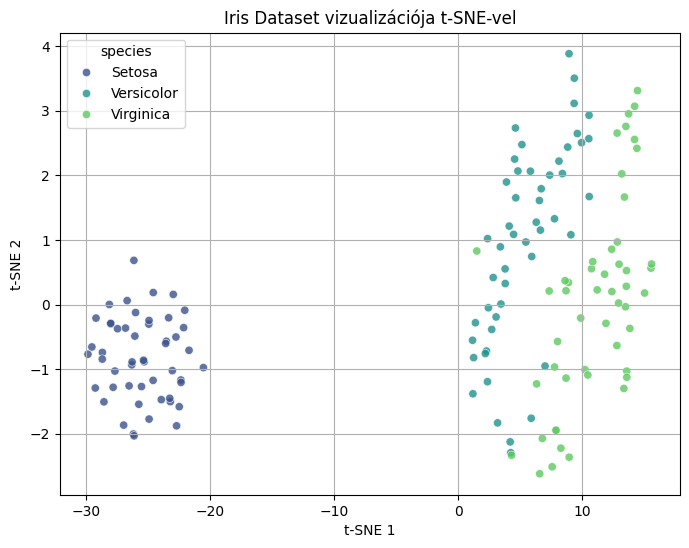

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. IRIS dataset betöltése
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target  # Célváltozó (0 = Setosa, 1 = Versicolor, 2 = Virginica)

# 2. Adatok normalizálása (Fontos a t-SNE esetében!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.iloc[:, :-1])  # Az utolsó oszlop (species) nélkül

# 3. t-SNE alkalmazása az adatokra (4 dimenzió -> 2 dimenzió)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 4. Eredmény vizualizálása
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df["species"].map({0: "Setosa", 1: "Versicolor", 2: "Virginica"}), palette="viridis", alpha=0.8)
plt.title("Iris Dataset vizualizációja t-SNE-vel")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid()
plt.show()


### Dokumentum-hasonlóság TF-IDF segítségével

A szöveges adatok összehasonlításához gyakran használjuk a **TF-IDF vektorizációt**, amely kiemeli a dokumentumokban fontos szavakat, miközben elnyomja a gyakori, kevésbé informatív kifejezéseket.  

- A dokumentumokat először TF-IDF vektorokká alakítjuk.  
- Ezután a vektorok közötti **koszinusz-hasonlóságot** számítjuk ki, amely megmutatja, hogy a két szöveg mennyire hasonló.  

Így egyszerűen mérhetjük a szövegek közötti tartalmi hasonlóságot, például mondatok, cikkek vagy keresési lekérdezések esetén.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Két mondat megadása helyesen
documents = ["I love deep learning", "Machine learning is amazing"]

# 2. TF-IDF vektorizáció alkalmazása
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(documents)

# 3. Sparse mátrix átalakítása tömbbé
vec1 = X_tfidf.toarray()[0]  # Az első mondat vektora
vec2 = X_tfidf.toarray()[1]  # A második mondat vektora

# 4. Kozinusz hasonlóság kiszámítása
sentence_similarity = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# 5. Eredmény kiírása
print(f"A két mondat hasonlósága: {sentence_similarity:.4f}")


A két mondat hasonlósága: 0.1708


In [ ]:
import numpy as np

#  1. Két mondat tokenizálása és vektorok létrehozása
sentence1 = ["I", "love", "deep", "learning"]
sentence2 = ["Machine", "learning", "is", "amazing"]

# 2. A mondatok szóvektorainak kiszámítása
vec1 = np.mean([word2vec_model[word] for word in sentence1 if word in word2vec_model], axis=0)
vec2 = np.mean([word2vec_model[word] for word in sentence2 if word in word2vec_model], axis=0)

# 3. Kozinusz hasonlóság számítása a két mondat között
sentence_similarity = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# 4. Eredmény kiírása
print(f"A két mondat hasonlósága: {sentence_similarity:.4f}")


A két mondat hasonlósága: 0.8934


### Szöveg hasonlóság mégése a SPAM dataset-en

- Viszgáljuk meg a hasonlóság mérést a SPAM dataset üzenetein.
- Nézzük, meg, hogy mely megoldás találja meg jobban a SMAP-okat a SPAM alapján.

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#  1. SMS Spam Dataset betöltése
url = "https://github.com/mohitgupta-1O1/Kaggle-SMS-Spam-Collection-Dataset-/raw/refs/heads/master/spam.csv"
df = pd.read_csv(url, sep=",", header=0, encoding='latin1', on_bad_lines='skip').iloc[:,:2].rename(columns={'v1':'label','v2':'message'})



In [ ]:

# 2. Egy tetszőleges üzenet definiálása (amit az egész datasethez hasonlítunk)
query_message = "Congratulations! You have won a free prize. Call now!"



### Szöveg-hasonlóság mérése a SPAM dataset-en

A szöveges hasonlóság mérése nemcsak dokumentumok vagy mondatok összehasonlítására használható,  
hanem gyakorlati problémák, például a **spam üzenetek felismerése** esetén is.

Ebben a példában a **SMS Spam Dataset** üzenetein vizsgáljuk meg, hogyan működik a hasonlóságmérés:

- Definiálunk egy új üzenetet (*"Congratulations! You have won a free prize. Call now!"*).  
- Az üzeneteket **TF-IDF vektorizációval** alakítjuk numerikus formára.  
- Az új üzenet és az adatbázis üzenetei közötti **koszinusz-hasonlóságot** számítjuk ki.  
- Megkeressük a 10 leginkább hasonló üzenetet, és megnézzük, hogy azok milyen címkével (ham vagy spam) szerepelnek.  

Ez jól szemlélteti, hogy a hasonlóság alapú megközelítés segíthet a **spam szűrésében**, hiszen a gyanús üzenetek jellemzően nagyon hasonlítanak a korábban ismert spamekre.




In [ ]:

# 3. TF-IDF vektorizáció az összes üzenetre és az új üzenetre
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df["message"].tolist() + [query_message])

# 4. Kozinusz hasonlóság számítása az új üzenet és az összes többi üzenet között
similarities = cosine_similarity(X_tfidf[-1:], X_tfidf[:-1]).flatten()

# 5. A 10 leghasonlóbb üzenet és címkéjének kiválasztása
df["similarity"] = similarities
top_10_similar = df.nlargest(10, "similarity")[["message", "label", "similarity"]]

top_10_similar

,message,label,similarity
3596,Congratulations YOU'VE Won. You're a Winner in...,spam,0.486319
494,Are you free now?can i call now?,ham,0.446401
2311,Congratulations! Thanks to a good friend U hav...,spam,0.395969
2824,Congratulations - Thanks to a good friend U ha...,spam,0.395969
3258,Congratulations! Thanks to a good friend U hav...,spam,0.395969
1873,You have WON a guaranteed å£1000 cash or a å£2...,spam,0.369562
2950,Hey now am free you can call me.,ham,0.347929
504,+123 Congratulations - in this week's competit...,spam,0.328069
2123,+123 Congratulations - in this week's competit...,spam,0.328069
4417,"When you get free, call me",ham,0.315263


Mit látunk?
- Bár a "Congratulations! You have won a free prize. Call now!" egyértelműan SMAP, A TF-IDF nem tudja ezt hatékonyan észlelni.
- Ennek oka, hogy a TF-IDF az "azonos szavak" előfordulását kódolja, és nem kezeli az "azonos jelentésű" mondatokat.

### Hasonlóság Word2Vec segítségével

A Bag-of-Words és TF-IDF megközelítések szavak előfordulására építenek,  
de nem veszik figyelembe a szavak **jelentésbeli hasonlóságát**.  

A **Word2Vec** ezzel szemben minden szót egy **sűrű, több száz dimenziós vektorban** reprezentál,  
ahol a hasonló jelentésű szavak vektorai is közel kerülnek egymáshoz.  

- Egy mondat vagy dokumentum vektorát úgy képezhetjük, hogy a szavait reprezentáló vektorokat **átlagoljuk**.  
- Ezután a dokumentumok közötti **koszinusz-hasonlóság** kiszámítható ezekből a mondatvektorokból.  
- Így nemcsak a közös szavakat, hanem a **jelentésbeli hasonlóságot** is figyelembe tudjuk venni.  

A módszer különösen hasznos olyan szöveges feladatoknál, ahol a szinonimák vagy hasonló értelmű kifejezések felismerése is fontos (pl. spam szűrés, keresés, ajánlórendszerek).


In [ ]:
import gensim.downloader as api
import numpy as np


# 2. Segédfüggvény egy mondat vektor reprezentációjára (átlagolja a szavak vektorait)
def get_sentence_vector(sentence):
    words = sentence.lower().split()  # Tokenizálás egyszerű szétválasztással
    vectors = [word2vec_model[word] for word in words if word in word2vec_model]  # Szóvektorok lekérése
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)  # Átlagolt vektor vagy nullvektor

# 3. A dataset minden üzenetének vektorizálása Word2Vec segítségével
df["vector"] = df["message"].apply(get_sentence_vector)

# 4. Tetszőleges új üzenet vektorizálása
query_vector = get_sentence_vector(query_message)

# 5. Kozinusz hasonlóság számítása az új üzenet és az összes többi üzenet között
df["similarity"] = df["vector"].apply(lambda x: np.dot(x, query_vector) / (np.linalg.norm(x) * np.linalg.norm(query_vector)) if np.linalg.norm(x) > 0 else 0)

#  6. A 10 leginkább hasonló üzenet kiválasztása
top_10_similar_w2v = df.nlargest(10, "similarity")[["message", "label", "similarity"]]

top_10_similar_w2v


,message,label,similarity
1117,"449050000301 You have won a å£2,000 price! To ...",spam,0.992600
803,You have won a guaranteed å£200 award or even ...,spam,0.984096
1969,You have won a guaranteed å£200 award or even ...,spam,0.978701
113,GENT! We are trying to contact you. Last weeke...,spam,0.975943
563,GENT! We are trying to contact you. Last weeke...,spam,0.975943
5468,URGENT! Last weekend's draw shows that you hav...,spam,0.975743
166,URGENT! We are trying to contact you. Last wee...,spam,0.974452
3805,URGENT! We are trying to contact you. Last wee...,spam,0.974452
5443,You have won a guaranteed 32000 award or maybe...,spam,0.974231
1535,You have won a Nokia 7250i. This is what you g...,spam,0.973612


Mit látunk?
- A "Congratulations! You have won a free prize. Call now!" egyértelműan SMAP, A Word2Vec jól tudja ezt észlelni.
- Ennek oka, hogy a Word2Vec kezeli az "azonos jelentésű" mondatokat.

### Dimenziócsökkentés képadatokon

A dimenziócsökkentés nemcsak szöveges és táblázatos adatoknál alkalmazható,  
hanem képek esetén is, ahol a képek pixeleit több száz vagy akár több ezer dimenzió írja le.  

Példa: egy 28x28 pixeles MNIST számjegykép **784 dimenziót** jelent.  
Ezt nehéz közvetlenül ábrázolni, de PCA vagy t-SNE segítségével  
2 dimenzióra vetíthetjük az adatokat, és így vizualizálhatjuk a számjegyek közötti klasztereket.  

Ez jól mutatja, hogy a dimenziócsökkentés általánosan használható eszköz,  
amely bármilyen nagy dimenziójú adat vizualizációját és elemzését megkönnyíti.

Bőveben a MNIST-ről [itt](https://en.wikipedia.org/wiki/MNIST_database)


In [59]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

# 1. MNIST-szerű digits dataset betöltése (8x8 pixeles számjegyek)
digits = load_digits()
X = digits.data      # képek (64 dimenziós vektorok)
y = digits.target    # címkék (0-9 számjegyek)

In [60]:
print('Egy minta:', y[0])
print('Egy minta vektora:', X[0])

Egy minta: 0
Egy minta vektora: [ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


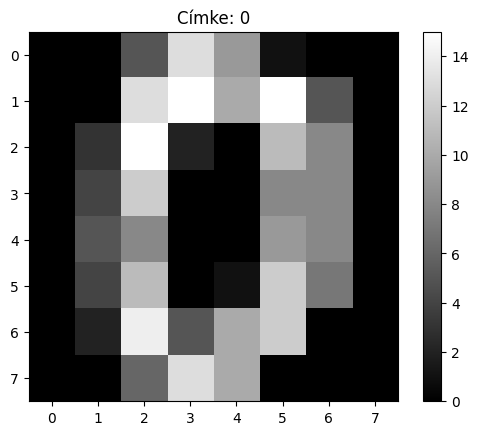

In [61]:
# Átalakítás képpé és megjelenítés
plt.imshow(X[0].reshape(8,8), cmap="gray")
plt.title(f"Címke: {y[0]}")
plt.colorbar()
plt.show()

### Hogyan néz ki egy minta vektorként és képként?

A képeket a gépi tanulási modellekben általában **vektorként** tároljuk: minden pixel egy-egy dimenzió.  
Például az `sklearn` `digits` dataset-ben egy 8×8 pixeles számjegykép **64 elemű vektorként** jelenik meg.  

- Vektorként: egy sor szám (0–16 értékekkel), amelyek a pixelek intenzitását jelentik.  
- Képként: a 64 szám visszaalakítható egy 8×8 mátrixba, amit vizualizálhatunk, és ekkor felismerhetővé válik maga a számjegy.  

Ez jól mutatja, hogy a **gépek számokkal dolgoznak**, de ugyanaz az adat számunkra képként sokkal érthetőbb.  


In [62]:
# 2. PCA alkalmazása 2 dimenzióra
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [63]:
print('Egy PCA minta vektora:',X_pca[0])

Egy PCA minta vektora: [ -1.25946645 -21.27488348]


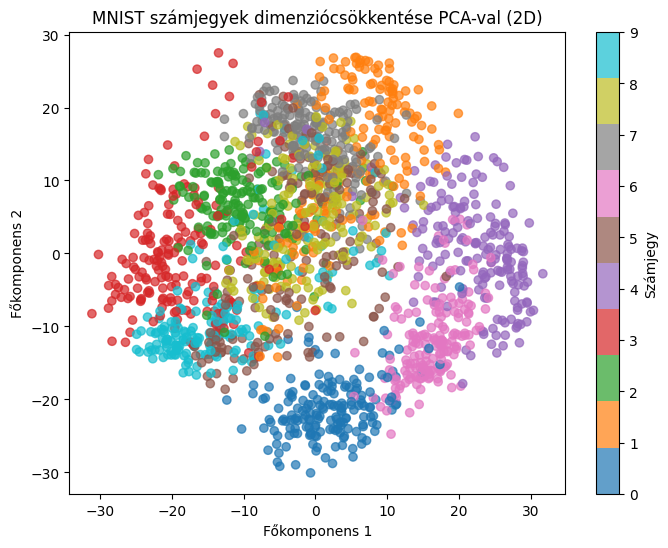

In [64]:
# 3. Eredmény vizualizálása
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="tab10", alpha=0.7)
plt.colorbar(scatter, label="Számjegy")
plt.title("MNIST számjegyek dimenziócsökkentése PCA-val (2D)")
plt.xlabel("Főkomponens 1")
plt.ylabel("Főkomponens 2")
plt.show()

### 1. FELADAT – Adatvizualizáció és felfedezés
- Cél: Az adathalmaz megtekintése, alapvető statisztikák és vizualizáció.
- sklearn.datasets.load_wine() dataset betöltése.
- pandas.DataFrame.describe(), info(), head() metódusokkal az adatok felfedezése.
- matplotlib és seaborn segítségével eloszlások, boxplotok és scatterplotok készítése.


### 2. FELADAT - Hasonlóság mérése a tabuláris adatok között
- Cél: Kiszámolni a hasonlóságot az adatsorok között különböző metrikákkal.
- Euklideszi távolság és Kozinusz hasonlóság (scipy.spatial.distance).
- KNN-alapú legközelebbi minta keresés (sklearn.neighbors.NearestNeighbors).


### 3. FELADAT – Dimenziócsökkentés és vizualizáció
- Cél: Az adatok dimenzióját PCA és t-SNE segítségével csökkenteni és vizualizálni.
- PCA (Principal Component Analysis) -> főkomponens-analízis alkalmazása.
- t-SNE (t-Distributed Stochastic Neighbor Embedding) -> vizualizáció 2D-ben.

### 4. FELADAT – KNN osztályozó a csökkentett dimenziós adatokon
- Cél: Megvizsgálni, hogyan változik egy KNN osztályozó teljesítménye a dimenziócsökkentés után.
- KNN osztályozó (KNeighborsClassifier).
- Összehasonlítani a teljesítményt eredeti vs. csökkentett dimenziós adatokon.
